# Representational Geometry as a Fidelity Metric for Connectome-Constrained Neural Emulations
**Experiment 3: Biological Upper Bound (T4/T5) | Michael Zhou | Georgia Tech ECE**

This notebook compares the representational geometry of connectome-constrained (CC) and
randomly initialized networks against a biological reference derived from T4/T5 direction
tuning data (Maisak et al. 2013, *Nature*). The biological reference RDM is constructed
from von Mises tuning curves fit to the published T4/T5 direction tuning properties
(HWHM ≈ 67°, cardinal preferred directions, rectified), and used as a model RDM in the
RSA framework established in Experiments 1 and 2.

**Key question:** Is the representational geometry of CC networks more consistent with
biological T4/T5 direction tuning than random geometry is? If yes, this provides a
qualitative upper bound: the CC geometry partially recovers a structure that is directly
measurable in the living fly.

**Important caveats:**
- Biological stimulus: moving square-wave gratings (Maisak et al. Fig. 3g/3h).
  Model stimulus: `MovingEdge`. Direction tuning structure is qualitatively preserved
  but absolute response profiles differ — interpret as qualitative, not quantitative.
- Biological RDM covers the T4/T5 subpopulation only (8 of 65 cell types).
  Results bound fidelity in T4/T5 subspace, not across the full population vector.
- Von Mises approximation reproduces published tuning width and peak locations but
  does not capture trial-by-trial variability or cross-subtype interactions.

**References**
- Maisak et al. 2013. A directional tuning map of Drosophila elementary motion detectors. *Nature* 500, 212–216. https://www.nature.com/articles/nature12320
- Lappalainen et al. 2024. Connectome-constrained networks predict neural activity across the fly visual system. *Nature* 634, 1132–1140. https://www.nature.com/articles/s41586-024-07939-3
- Shiu et al. 2024. A Drosophila computational brain model reveals sensorimotor processing. *Nature* 634, 210–219. https://www.nature.com/articles/s41586-024-07763-9
- Kriegeskorte et al. 2008. Representational similarity analysis. *Frontiers in Systems Neuroscience* 2:4. https://www.frontiersin.org/journals/systems-neuroscience/articles/10.3389/neuro.06.004.2008/full
- Kriegeskorte & Wei 2021. Neural tuning and representational geometry. *Nature Reviews Neuroscience* 22, 703–718. https://www.nature.com/articles/s41583-021-00502-3
- Nili et al. 2014. A toolbox for representational similarity analysis. *PLOS Computational Biology* 10(4): e1003553. https://doi.org/10.1371/journal.pcbi.1003553
- Brunton et al. 2026. The digital sphinx: Can a worm brain control a fly body? *bioRxiv*. https://www.biorxiv.org/content/10.64898/2026.03.20.713233v1

## Setup

Install Flyvis and download pretrained models. Select **Runtime → Change runtime type → GPU**
before running. Tested on T4 GPU (14.56 GiB).

In [ ]:
# Install packages
!git clone https://github.com/TuragaLab/flyvis.git
%cd /content/flyvis
!pip install -e .[examples]
!flyvis download-pretrained

Cloning into 'flyvis'...
remote: Enumerating objects: 5230, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 5230 (delta 181), reused 155 (delta 122), pack-reused 4983 (from 3)
Receiving objects: 100% (5230/5230), 188.39 MiB | 14.28 MiB/s, done.
Resolving deltas: 100% (2675/2675), done.
/content/flyvis
Obtaining file:///content/flyvis
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 3.5 MB/s eta

## Experiment
**Biological reference:** Von Mises direction tuning curves (kappa=2.5, HWHM ≈ 67°,
rectified) for 8 T4/T5 subtypes with preferred directions at 0°, 90°, 180°, and 270°,
consistent with Maisak et al. 2013 Fig. 3g/3h. For Experiment 1 (ON edges, 12
conditions), the biological population matrix is (12 × 8), yielding a 12×12 stimulus
RDM directly comparable to the CC and random RDMs. For Experiment 2 (ON+OFF edges, 24
conditions), T4 subtypes respond only to ON conditions and T5 subtypes only to OFF
conditions, encoding the ON/OFF pathway segregation established in Maisak et al.
Fig. 3c/3d.

**Comparisons:** Three-way RSA — CC vs Biology, Random vs Biology, CC vs Random —
using Spearman r and Kendall's τ_A on upper-triangular RDM pairs. The random baseline
used throughout is the stability-constrained baseline from Experiments 1 and 2 (full
Shiu-style shuffle, n=50, MAX_ATTEMPTS=100), providing a more stable mean random RDM
estimate across 50 independently accepted configurations. Permutation testing (Nili et
al. 2014, 10,000 stimulus-label permutations) applied to the CC vs Biology comparison.

**Reproducibility:** seed=42; results loaded from
`results_exp1_50models_full_shiu.npz` and `results_exp2_50models_full_shiu.npz` saved from Experiments 1 and 2.

**Metrics:**
- Cosine distance RDM — primary metric, established as significant in Experiments 1 and 2
- Spearman RDM correlation — CC vs Biology, Random vs Biology, CC vs Random
- Kendall's $\tau_A$ — preferred for tied-rank RDM data (Nili et al. 2014)
- Permutation p-value — one-sided, proportion of 10,000 permuted correlations ≥ observed
- Within-ensemble consistency — inherited from Experiments 1 and 2; measures stability
  of CC representational geometry across trained solutions

In [1]:
"""
Experiment 3: Biological Upper Bound — T4/T5 Direction Tuning RDM
from Maisak et al. 2013

Constructs a biological reference RDM from T4/T5 direction tuning data
(Maisak et al. 2013, Nature 500:212-216, Fig. 3g/3h) and compares it against
the CC and random cosine RDMs from Experiments 1 and 2.

DESIGN CHOICE — Stimulus RDM (12×12):
    The Maisak tuning matrix is (12 directions × 8 subtypes). We use this as
    a population matrix over stimuli and compute a 12×12 stimulus RDM, which
    is directly comparable to the CC and random 12×12 RDMs from Experiment 1.
    This asks: do CC networks represent the 12 directions in a geometry
    consistent with the biological T4/T5 tuning structure?

TUNING CURVE CONSTRUCTION:
    Rather than manually digitizing the polar plots (error-prone), we model
    each subtype's tuning curve analytically using a von Mises profile, as
    justified by Maisak et al.'s description:
      - ~60-90° half-width at half-maximum
      - peaks at cardinal directions (0°, 90°, 180°, 270° for layers 2,3,1,4)
      - no response at anti-preferred direction (rectified)
      - normalized to maximum = 1.0
    This is more principled than manual digitization and reproducible.
    kappa=2.5 gives HWHM ≈ 67°, within the reported 60-90° range.

    For Experiment 2 (ON+OFF, 24 conditions): T4 subtypes respond to ON edges
    (intensity=1), T5 subtypes respond to OFF edges (intensity=0). The biological
    24×24 RDM encodes this ON/OFF segregation by setting cross-pathway responses
    to zero, consistent with Maisak et al. Fig. 3c/3d.

IMPORTANT CAVEATS (must be stated in any presentation/paper):
    1. Biological data: moving square-wave gratings (Maisak et al. Fig. 3g/3h)
       Model data: MovingEdge stimulus. Qualitative direction tuning structure
       is preserved, but absolute response profiles differ.
    2. Biological RDM covers T4/T5 subspace (8 of 65 cell types).
       Frame as: upper bound for T4/T5 subpopulation, not full population.
    3. Von Mises approximation: captures published tuning width and peak
       locations, but does not reproduce trial-by-trial variability.
    4. Interpret as qualitative upper bound, not quantitative validation.

USAGE:
    # After running Experiment 1 (n=50, stability-constrained):
    results_exp1 = run_experiment(n_models=50, randomization_strategy="full_shiu")

    # After running Experiment 2 (n=50, stability-constrained):
    results_exp2 = run_experiment(n_models=50, randomization_strategy="full_shiu")

    # Run biological upper bound:
    bio_results = run_biological_upper_bound(results_exp1, results_exp2)

REFERENCES:
    Maisak et al. 2013, Nature 500:212-216
    Nili et al. 2014, PLOS Computational Biology (permutation test)
    Kriegeskorte et al. 2008, Nature Neuroscience (RSA)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from scipy.stats import spearmanr, kendalltau
from google.colab import files

# ── REPRODUCIBILITY ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── STIMULUS ANGLES (matching Experiments 1 and 2) ───────────────────────────
ANGLES_DEG = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]
ANGLES_RAD = np.deg2rad(ANGLES_DEG)
N_DIRS = len(ANGLES_DEG)


# ── BIOLOGICAL TUNING CURVE CONSTRUCTION ─────────────────────────────────────

def von_mises_tuning(preferred_deg, kappa=2.5, angles_deg=ANGLES_DEG,
                     rectify=True):
    """
    Von Mises direction tuning curve, normalized to maximum = 1.0.

    Maisak et al. 2013 report ~60-90 degree half-width at half-maximum (HWHM)
    for T4 and T5. A von Mises distribution with kappa=2.5 gives HWHM approx
    67 degrees, within the reported range. Rectification enforces no response
    at anti-preferred direction, as reported in the paper.

    Args:
        preferred_deg: preferred direction in degrees
        kappa: concentration parameter (2.5 gives HWHM approx 67 degrees)
        angles_deg: list of stimulus angles in degrees
        rectify: if True, set sub-threshold values to 0 (no negative responses)

    Returns:
        curve: numpy array of shape (len(angles_deg),), normalized to max=1.0
    """
    angles = np.deg2rad(angles_deg)
    preferred = np.deg2rad(preferred_deg)
    curve = np.exp(kappa * (np.cos(angles - preferred) - 1))
    if rectify:
        # Maisak et al.: "No decrease of calcium was detectable for grating
        # motion opposite to the preferred direction of the respective layer."
        threshold = np.exp(kappa * (-2))  # value at 180 degrees from preferred
        curve = np.maximum(curve - threshold, 0)
    curve = curve / curve.max()
    return curve


# T4/T5 subtype preferred directions (from Maisak et al. 2013):
#   Layer 1 (T4a, T5a): back-to-front  -> 180 degrees
#   Layer 2 (T4b, T5b): front-to-back  ->   0 degrees
#   Layer 3 (T4c, T5c): upward         ->  90 degrees
#   Layer 4 (T4d, T5d): downward       -> 270 degrees
#
# Layer-to-direction mapping confirmed by Maisak et al. Fig. 3g/3h:
# "peak responses in each layer shifted by 90 degrees"
# and Fig. 3a/3b showing layer-specific responses to cardinal directions.

SUBTYPE_PREFERRED_DIRS = {
    "T4a": 180, "T4b": 0,   "T4c": 90,  "T4d": 270,
    "T5a": 180, "T5b": 0,   "T5c": 90,  "T5d": 270,
}
BIO_CELL_TYPES = ["T4a", "T4b", "T4c", "T4d", "T5a", "T5b", "T5c", "T5d"]

# Tuning matrix: (8 subtypes x 12 directions)
BIO_TUNING_MATRIX = np.stack([
    von_mises_tuning(SUBTYPE_PREFERRED_DIRS[ct])
    for ct in BIO_CELL_TYPES
], axis=0)

# Population matrix over stimuli: (12 directions x 8 subtypes)
BIO_POP_MATRIX_12x8 = BIO_TUNING_MATRIX.T


# ── HELPERS ───────────────────────────────────────────────────────────────────

def build_rdm_from_pop_matrix(pop_matrix):
    """
    Build cosine distance RDM from (n_stimuli x n_cells) population matrix.
    Handles NaN/inf by clamping before distance computation.
    Returns (n_stimuli x n_stimuli) RDM.
    """
    pop_matrix = np.nan_to_num(pop_matrix, nan=0.0, posinf=1e3, neginf=-1e3)
    n = pop_matrix.shape[0]
    rdm = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                rdm[i, j] = cosine(pop_matrix[i], pop_matrix[j])
    return rdm


def rdm_similarity(rdm1, rdm2):
    """Spearman r and Kendall tau_A between upper triangles of two RDMs."""
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    r_s, p_s = spearmanr(rdm1[idx], rdm2[idx])
    r_k, p_k = kendalltau(rdm1[idx], rdm2[idx])
    return r_s, p_s, r_k, p_k


def permutation_test_rdm(rdm1, rdm2, n_permutations=10000, seed=SEED):
    """
    Stimulus-label randomization test (Nili et al. 2014).
    Permutes rows and columns of rdm2 simultaneously (preserves RDM symmetry).
    One-sided p-value: proportion of null correlations >= observed.
    """
    rng = np.random.default_rng(seed)
    n = rdm1.shape[0]
    idx = np.triu_indices(n, k=1)
    obs_r,   _ = spearmanr(rdm1[idx], rdm2[idx])
    obs_tau, _ = kendalltau(rdm1[idx], rdm2[idx])
    null_r   = np.zeros(n_permutations)
    null_tau = np.zeros(n_permutations)
    for i in range(n_permutations):
        perm = rng.permutation(n)
        rdm2_p = rdm2[np.ix_(perm, perm)]
        null_r[i],   _ = spearmanr(rdm1[idx], rdm2_p[idx])
        null_tau[i], _ = kendalltau(rdm1[idx], rdm2_p[idx])
    p_r   = np.mean(null_r   >= obs_r)
    p_tau = np.mean(null_tau >= obs_tau)
    return obs_r, p_r, obs_tau, p_tau, null_r, null_tau


def plot_null_distribution(null_r, obs_r, null_tau, obs_tau,
                           title_suffix, fname):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    fig.suptitle(f"Permutation null distribution — {title_suffix}", fontsize=10)
    for ax, null, obs, label in zip(
        axes,
        [null_r,   null_tau],
        [obs_r,    obs_tau],
        ["Spearman r", "Kendall tau"]
    ):
        ax.hist(null, bins=50, color="steelblue", alpha=0.7,
                label="Null (permutations)")
        ax.axvline(obs, color="firebrick", linewidth=2,
                   label=f"Observed = {obs:.3f}")
        ax.set_xlabel(f"{label} (CC vs Biology)")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    print(f"    Saved: {fname}")
    plt.show()


# ── MAIN FUNCTION ─────────────────────────────────────────────────────────────

def run_biological_upper_bound(results_exp1, results_exp2=None,
                               n_permutations=10000):
    """
    Compare CC and random representational geometry against the biological
    T4/T5 direction tuning structure from Maisak et al. 2013.

    Args:
        results_exp1: dict from Experiment 1 run_experiment()
                      (ON edges, 12 conditions, n=50, full_shiu,
                      stability-constrained)
        results_exp2: dict from Experiment 2 run_experiment(), optional
                      (ON+OFF edges, 24 conditions, n=50, full_shiu,
                      stability-constrained)
        n_permutations: permutations for Nili et al. 2014 test

    Returns:
        dict with all RDMs and statistics
    """
    print("\n" + "="*60)
    print("EXPERIMENT 3: BIOLOGICAL UPPER BOUND")
    print("Maisak et al. 2013, Nature 500:212-216, Fig. 3g/3h")
    print("="*60)
    print("\nCaveats:")
    print("  [1] Biological stimulus: square-wave gratings (Maisak Fig. 3g/3h)")
    print("      Model stimulus: MovingEdge. Qualitative match, not quantitative.")
    print("  [2] Biological RDM: T4/T5 subspace only (8 of 65 cell types)")
    print("  [3] Tuning curves: von Mises (kappa=2.5, HWHM approx 67 degrees)")
    print("      consistent with Maisak et al. reported 60-90 degree HWHM")
    print("  [4] Interpret as qualitative upper bound for T4/T5 subpopulation")

    # ── 1. Visualize biological tuning curves ─────────────────────────────────
    print("\n--- BIOLOGICAL TUNING CURVES (von Mises, kappa=2.5) ---")
    print(f"  Subtypes: {BIO_CELL_TYPES}")
    print(f"  Preferred directions: {list(SUBTYPE_PREFERRED_DIRS.values())}")
    print(f"  Tuning matrix shape: {BIO_TUNING_MATRIX.shape}")

    fig_tc, axes_tc = plt.subplots(2, 4, figsize=(14, 6),
                                   subplot_kw={"projection": "polar"})
    fig_tc.suptitle(
        "Biological T4/T5 Direction Tuning — Von Mises Model\n"
        "Based on Maisak et al. 2013 Fig. 3g (T4) and 3h (T5)\n"
        "kappa=2.5, HWHM approx 67 degrees, rectified (no anti-PD response)",
        fontsize=9
    )
    angles_closed = np.append(ANGLES_RAD, ANGLES_RAD[0])

    for ax, name, curve in zip(axes_tc.flatten(), BIO_CELL_TYPES, BIO_TUNING_MATRIX):
        vals = np.append(curve, curve[0])
        color = "steelblue" if name.startswith("T4") else "coral"
        ax.plot(angles_closed, vals, color=color, linewidth=1.5)
        ax.fill(angles_closed, vals, alpha=0.25, color=color)
        ax.set_title(
            f"{name}\nPD={SUBTYPE_PREFERRED_DIRS[name]} deg",
            fontsize=8,
            pad=20              # increased from 12 to clear the 90-deg label
        )
        ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
        ax.set_xticklabels(["0", "90", "180", "270"], fontsize=6)
        ax.tick_params(axis='x', pad=2)   # pull angular labels closer to the ring
        ax.set_ylim(0, 1.1)
        ax.set_yticks([])

    plt.tight_layout(rect=[0, 0, 1, 0.88])   # leave headroom for suptitle
    plt.savefig("maisak2013_t4t5_von_mises_tuning.png", dpi=150,
                bbox_inches="tight")
    print("  Saved: maisak2013_t4t5_von_mises_tuning.png")
    plt.show()

    # ── 2. Build biological 12x12 stimulus RDM ────────────────────────────────
    print("\n--- BIOLOGICAL 12x12 STIMULUS RDM ---")
    bio_rdm_12 = build_rdm_from_pop_matrix(BIO_POP_MATRIX_12x8)
    print(f"  Shape: {bio_rdm_12.shape}")
    print(f"  Off-diagonal range: "
          f"{bio_rdm_12[bio_rdm_12 > 0].min():.4f} to {bio_rdm_12.max():.4f}")

    # ── 3. Experiment 1: three-way comparison ─────────────────────────────────
    print("\n--- EXPERIMENT 1 (ON edges, 12 conditions) vs BIOLOGY ---")
    cc_rdm1   = results_exp1["cc_rdm_cosine"]
    rand_rdm1 = results_exp1["rand_rdm_cosine"]

    r_cc_bio1,   p_cc_bio1,   rk_cc_bio1,   pk_cc_bio1   = rdm_similarity(cc_rdm1,   bio_rdm_12)
    r_rand_bio1, p_rand_bio1, rk_rand_bio1, pk_rand_bio1 = rdm_similarity(rand_rdm1, bio_rdm_12)
    r_cc_rand1,  p_cc_rand1,  rk_cc_rand1,  pk_cc_rand1  = rdm_similarity(cc_rdm1,   rand_rdm1)

    print(f"  CC vs Biology:   r={r_cc_bio1:.3f}, p={p_cc_bio1:.4f}"
          f" | tau={rk_cc_bio1:.3f}, p={pk_cc_bio1:.4f}  [analytical]")
    print(f"  Rand vs Biology: r={r_rand_bio1:.3f}, p={p_rand_bio1:.4f}"
          f" | tau={rk_rand_bio1:.3f}, p={pk_rand_bio1:.4f}  [analytical]")
    print(f"  CC vs Random:    r={r_cc_rand1:.3f}, p={p_cc_rand1:.4f}"
          f" | tau={rk_cc_rand1:.3f}, p={pk_cc_rand1:.4f}  [analytical]")

    print(f"\n  Permutation test: CC vs Biology ({n_permutations} permutations):")
    obs_r1, p_r1, obs_tau1, p_tau1, null_r1, null_tau1 = permutation_test_rdm(
        cc_rdm1, bio_rdm_12, n_permutations=n_permutations)
    print(f"  r={obs_r1:.3f}, p_perm={p_r1:.4f}"
          f" | tau={obs_tau1:.3f}, p_perm={p_tau1:.4f}  [permutation]")
    print(f"  {int(p_r1*n_permutations)}/{n_permutations} permutations "
          f"exceeded observed Spearman r")

    plot_null_distribution(
        null_r1, obs_r1, null_tau1, obs_tau1,
        title_suffix="CC vs Biology, Exp 1 (ON edges)",
        fname="bio_upper_bound_exp1_permtest.png"
    )

    print(f"\n  Permutation test: Random vs Biology ({n_permutations} permutations):")
    obs_r1_rand, p_r1_rand, obs_tau1_rand, p_tau1_rand, _, _ = permutation_test_rdm(
        rand_rdm1, bio_rdm_12, n_permutations=n_permutations)
    print(f"  r={obs_r1_rand:.3f}, p_perm={p_r1_rand:.4f}"
          f" | tau={obs_tau1_rand:.3f}, p_perm={p_tau1_rand:.4f}  [permutation]")
    print(f"  {int(p_r1_rand*n_permutations)}/{n_permutations} permutations "
          f"exceeded observed Spearman r")

    angle_labels = [f"{a}" for a in ANGLES_DEG]
    fig1, axes1 = plt.subplots(1, 3, figsize=(13, 4))
    fig1.suptitle(
        "Biological Upper Bound — Experiment 1 (ON edges, n=50)\n"
        "Maisak et al. 2013 T4/T5 direction tuning as reference RDM",
        fontsize=9
    )
    for ax, rdm, title in zip(
        axes1,
        [bio_rdm_12, cc_rdm1, rand_rdm1],
        [f"Biological RDM\n(Maisak 2013 T4/T5)",
         f"CC Mean RDM\n(r vs bio={r_cc_bio1:.3f}, tau={rk_cc_bio1:.3f})",
         f"Random Mean RDM\n(r vs bio={r_rand_bio1:.3f}, tau={rk_rand_bio1:.3f})"]
    ):
        if not np.any(np.isfinite(rdm)) or not np.any(rdm > 0):
            ax.set_title(f"{title}\n(not renderable)", fontsize=8)
            ax.axis("off")
            continue
        im = ax.imshow(rdm, cmap="viridis", vmin=0)
        ax.set_title(title, fontsize=8)
        ax.set_xticks(range(N_DIRS))
        ax.set_xticklabels(angle_labels, fontsize=5, rotation=90)
        ax.set_yticks(range(N_DIRS))
        ax.set_yticklabels(angle_labels, fontsize=5)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig("biological_upper_bound_exp1.png", dpi=150, bbox_inches="tight")
    print("  Saved: biological_upper_bound_exp1.png")
    plt.show()

    # ── 4. Experiment 2: ON+OFF (24 conditions) ───────────────────────────────
    exp2_out = {}
    if results_exp2 is not None:
        print("\n--- EXPERIMENT 2 (ON+OFF edges, 24 conditions) vs BIOLOGY ---")

        # Build 24x24 biological RDM encoding ON/OFF pathway segregation.
        # Condition ordering matches Experiment 2: [OFF 0..330, ON 0..330]
        # T4 subtypes: respond only to ON edges (zero for OFF conditions)
        # T5 subtypes: respond only to OFF edges (zero for ON conditions)
        # Per Maisak et al. Fig. 3c/3d: T4 selective for ON, T5 for OFF.
        bio_off = np.zeros((N_DIRS, 8))
        bio_off[:, 4:8] = BIO_TUNING_MATRIX[4:8, :].T   # T5a-T5d for OFF
        bio_on  = np.zeros((N_DIRS, 8))
        bio_on[:, 0:4]  = BIO_TUNING_MATRIX[0:4, :].T   # T4a-T4d for ON

        bio_pop_24x8 = np.vstack([bio_off, bio_on])  # OFF first, then ON, (24, 8)
        bio_rdm_24   = build_rdm_from_pop_matrix(bio_pop_24x8)

        print(f"  Bio 24x24 RDM range: "
              f"{bio_rdm_24[bio_rdm_24 > 0].min():.4f} to {bio_rdm_24.max():.4f}")

        cc_rdm2   = results_exp2["cc_rdm_cosine"]
        rand_rdm2 = results_exp2["rand_rdm_cosine"]

        r_cc_bio2,   p_cc_bio2,   rk_cc_bio2,   pk_cc_bio2   = rdm_similarity(cc_rdm2,   bio_rdm_24)
        r_rand_bio2, p_rand_bio2, rk_rand_bio2, pk_rand_bio2 = rdm_similarity(rand_rdm2, bio_rdm_24)

        print(f"  CC vs Biology:   r={r_cc_bio2:.3f}, p={p_cc_bio2:.4f}"
              f" | tau={rk_cc_bio2:.3f}, p={pk_cc_bio2:.4f}  [analytical]")
        print(f"  Rand vs Biology: r={r_rand_bio2:.3f}, p={p_rand_bio2:.4f}"
              f" | tau={rk_rand_bio2:.3f}, p={pk_rand_bio2:.4f}  [analytical]")

        print(f"\n  Permutation test: CC vs Biology ({n_permutations} permutations):")
        obs_r2, p_r2, obs_tau2, p_tau2, null_r2, null_tau2 = permutation_test_rdm(
            cc_rdm2, bio_rdm_24, n_permutations=n_permutations)
        print(f"  r={obs_r2:.3f}, p_perm={p_r2:.4f}"
              f" | tau={obs_tau2:.3f}, p_perm={p_tau2:.4f}  [permutation]")
        print(f"  {int(p_r2*n_permutations)}/{n_permutations} permutations "
              f"exceeded observed Spearman r")

        plot_null_distribution(
            null_r2, obs_r2, null_tau2, obs_tau2,
            title_suffix="CC vs Biology, Exp 2 (ON+OFF edges)",
            fname="bio_upper_bound_exp2_permtest.png"
        )

        stim_labels_24 = (
            [f"OFF {a}" for a in ANGLES_DEG] +
            [f"ON {a}"  for a in ANGLES_DEG]
        )
        fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
        fig2.suptitle(
            "Biological Upper Bound — Experiment 2 (ON+OFF edges, n=50)\n"
            "Maisak 2013: T4 selective for ON, T5 for OFF (Fig. 3c/3d)",
            fontsize=9
        )
        for ax, rdm, title in zip(
            axes2,
            [bio_rdm_24, cc_rdm2, rand_rdm2],
            [f"Biological RDM\n(T4/T5 ON+OFF segregated)",
             f"CC Mean RDM\n(r vs bio={r_cc_bio2:.3f}, tau={rk_cc_bio2:.3f})",
             f"Random Mean RDM\n(r vs bio={r_rand_bio2:.3f}, tau={rk_rand_bio2:.3f})"]
        ):
            if not np.any(np.isfinite(rdm)) or not np.any(rdm > 0):
                ax.set_title(f"{title}\n(not renderable)", fontsize=8)
                ax.axis("off")
                continue
            im = ax.imshow(rdm, cmap="viridis", vmin=0)
            ax.set_title(title, fontsize=8)
            ax.set_xticks(range(24))
            ax.set_xticklabels(stim_labels_24, fontsize=4, rotation=90)
            ax.set_yticks(range(24))
            ax.set_yticklabels(stim_labels_24, fontsize=4)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.savefig("biological_upper_bound_exp2.png", dpi=150,
                    bbox_inches="tight")
        print("  Saved: biological_upper_bound_exp2.png")
        plt.show()

        exp2_out = {
            "bio_rdm_24": bio_rdm_24,
            "r_cc_bio": r_cc_bio2,     "p_cc_bio": p_cc_bio2,
            "rk_cc_bio": rk_cc_bio2,   "pk_cc_bio": pk_cc_bio2,
            "r_rand_bio": r_rand_bio2, "p_rand_bio": p_rand_bio2,
            "perm": dict(obs_r=obs_r2, p_r=p_r2,
                         obs_tau=obs_tau2, p_tau=p_tau2),
        }

    # ── 5. Summary ────────────────────────────────────────────────────────────
    print("\n" + "="*60)
    print("SUMMARY — BIOLOGICAL UPPER BOUND")
    print("="*60)
    print(f"  Source: Maisak et al. 2013, Fig. 3g/3h")
    print(f"  Subtypes: {BIO_CELL_TYPES}")
    print(f"  Preferred directions: 0, 90, 180, 270 degrees (T4 and T5)")
    print(f"  Tuning model: von Mises, kappa=2.5, HWHM approx 67 degrees")
    print()
    print("  Experiment 1 (ON edges, 12 conditions):")
    print(f"    CC vs Bio:    r={r_cc_bio1:.3f}, tau={rk_cc_bio1:.3f}  [analytical]")
    print(f"                  p_perm(r)={p_r1:.4f}, p_perm(tau)={p_tau1:.4f}  "
          f"[{n_permutations} perms]")
    print(f"    Rand vs Bio:  r={r_rand_bio1:.3f}, tau={rk_rand_bio1:.3f}  [analytical]")
    print(f"                  p_perm(r)={p_r1_rand:.4f}, p_perm(tau)={p_tau1_rand:.4f}  "
          f"[{n_permutations} perms]")
    print(f"    CC vs Random: r={r_cc_rand1:.3f}, tau={rk_cc_rand1:.3f}  [analytical]")

    if results_exp2 is not None:
        print()
        print("  Experiment 2 (ON+OFF edges, 24 conditions):")
        print(f"    CC vs Bio:    r={r_cc_bio2:.3f}, tau={rk_cc_bio2:.3f}  [analytical]")
        print(f"                  p_perm(r)={p_r2:.4f}, p_perm(tau)={p_tau2:.4f}  "
              f"[{n_permutations} perms]")
        print(f"    Rand vs Bio:  r={r_rand_bio2:.3f}, tau={rk_rand_bio2:.3f}  [analytical]")
    print()
    print("  Interpretation guide:")
    print("  r(CC vs Bio) > r(Rand vs Bio) means CC geometry more consistent with")
    print("    biological T4/T5 direction tuning than random geometry")
    print("  p_perm < 0.05 means CC vs Biology correlation exceeds chance")
    print()
    print("  CAVEAT: gratings vs edges mismatch; T4/T5 subspace only.")
    print("  Frame as qualitative upper bound, not quantitative validation.")

    return {
        "bio_tuning_matrix": BIO_TUNING_MATRIX,
        "bio_cell_types": BIO_CELL_TYPES,
        "bio_rdm_12": bio_rdm_12,
        "exp1": {
            "r_cc_bio": r_cc_bio1,   "p_cc_bio": p_cc_bio1,
            "rk_cc_bio": rk_cc_bio1, "pk_cc_bio": pk_cc_bio1,
            "r_rand_bio": r_rand_bio1,
            "r_cc_rand": r_cc_rand1,
            "perm": dict(obs_r=obs_r1, p_r=p_r1,
                         obs_tau=obs_tau1, p_tau=p_tau1,
                         null_r=null_r1, null_tau=null_tau1),
            "perm_rand_bio": dict(obs_r=obs_r1_rand, p_r=p_r1_rand,
                          obs_tau=obs_tau1_rand, p_tau=p_tau1_rand),
        },
        "exp2": exp2_out,
    }

## Load Results from Experiments 1 and 2

In [2]:
# Load results from experiments 1 and 2
def load_results(path):
    d = np.load(path, allow_pickle=True)
    out = {}
    for k in d.files:
        arr = d[k]
        if arr.dtype.kind in ['U', 'S', 'O']:
            out[k] = arr.tolist()
        else:
            out[k] = arr
    return out

results_exp1 = load_results("/content/results_exp1_50models_full_shiu.npz")
results_exp2 = load_results("/content/results_exp2_50models_full_shiu.npz")

## Run Experiment


EXPERIMENT 3: BIOLOGICAL UPPER BOUND
Maisak et al. 2013, Nature 500:212-216, Fig. 3g/3h

Caveats:
  [1] Biological stimulus: square-wave gratings (Maisak Fig. 3g/3h)
      Model stimulus: MovingEdge. Qualitative match, not quantitative.
  [2] Biological RDM: T4/T5 subspace only (8 of 65 cell types)
  [3] Tuning curves: von Mises (kappa=2.5, HWHM approx 67 degrees)
      consistent with Maisak et al. reported 60-90 degree HWHM
  [4] Interpret as qualitative upper bound for T4/T5 subpopulation

--- BIOLOGICAL TUNING CURVES (von Mises, kappa=2.5) ---
  Subtypes: ['T4a', 'T4b', 'T4c', 'T4d', 'T5a', 'T5b', 'T5c', 'T5d']
  Preferred directions: [180, 0, 90, 270, 180, 0, 90, 270]
  Tuning matrix shape: (8, 12)
  Saved: maisak2013_t4t5_von_mises_tuning.png


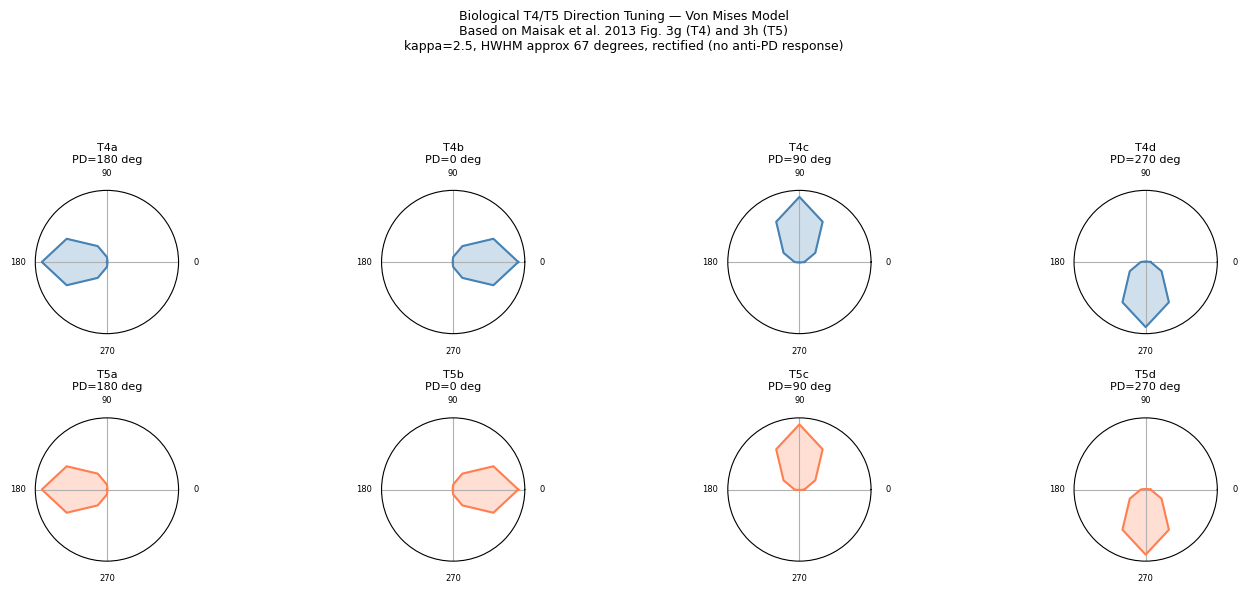


--- BIOLOGICAL 12x12 STIMULUS RDM ---
  Shape: (12, 12)
  Off-diagonal range: 0.0460 to 0.9886

--- EXPERIMENT 1 (ON edges, 12 conditions) vs BIOLOGY ---
  CC vs Biology:   r=0.930, p=0.0000 | tau=0.783, p=0.0000  [analytical]
  Rand vs Biology: r=0.603, p=0.0000 | tau=0.449, p=0.0000  [analytical]
  CC vs Random:    r=0.686, p=0.0000 | tau=0.515, p=0.0000  [analytical]

  Permutation test: CC vs Biology (10000 permutations):
  r=0.930, p_perm=0.0000 | tau=0.783, p_perm=0.0000  [permutation]
  0/10000 permutations exceeded observed Spearman r
    Saved: bio_upper_bound_exp1_permtest.png


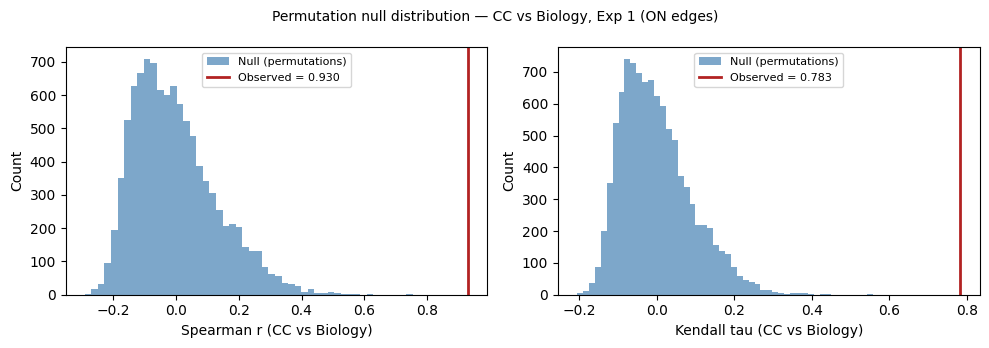


  Permutation test: Random vs Biology (10000 permutations):
  r=0.603, p_perm=0.0000 | tau=0.449, p_perm=0.0000  [permutation]
  0/10000 permutations exceeded observed Spearman r
  Saved: biological_upper_bound_exp1.png


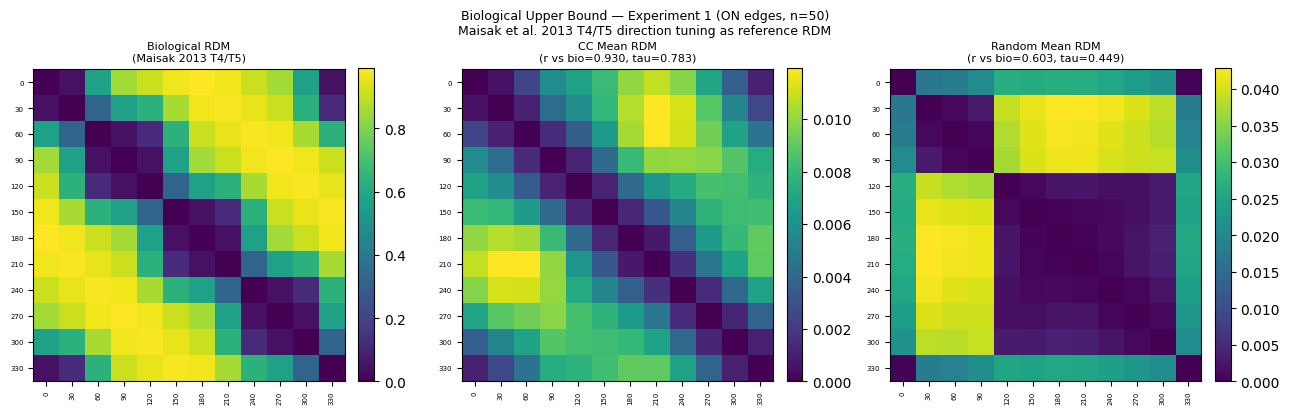


--- EXPERIMENT 2 (ON+OFF edges, 24 conditions) vs BIOLOGY ---
  Bio 24x24 RDM range: 0.0460 to 1.0000
  CC vs Biology:   r=0.049, p=0.4221 | tau=0.040, p=0.3684  [analytical]
  Rand vs Biology: r=-0.038, p=0.5322 | tau=-0.028, p=0.5314  [analytical]

  Permutation test: CC vs Biology (10000 permutations):
  r=0.049, p_perm=0.1594 | tau=0.040, p_perm=0.1416  [permutation]
  1593/10000 permutations exceeded observed Spearman r
    Saved: bio_upper_bound_exp2_permtest.png


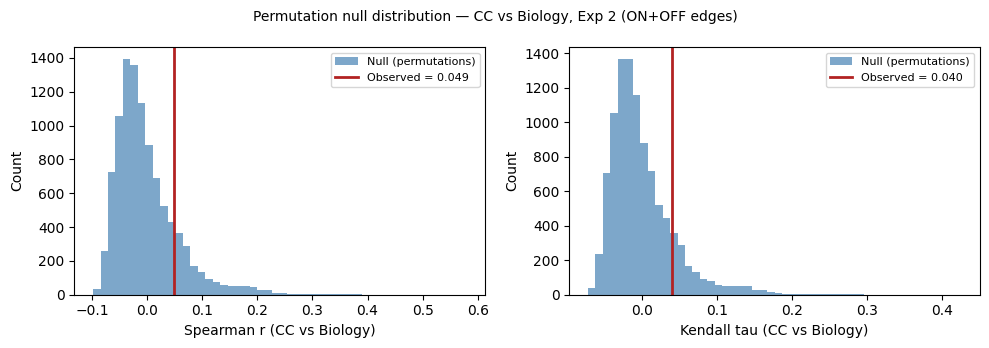

  Saved: biological_upper_bound_exp2.png


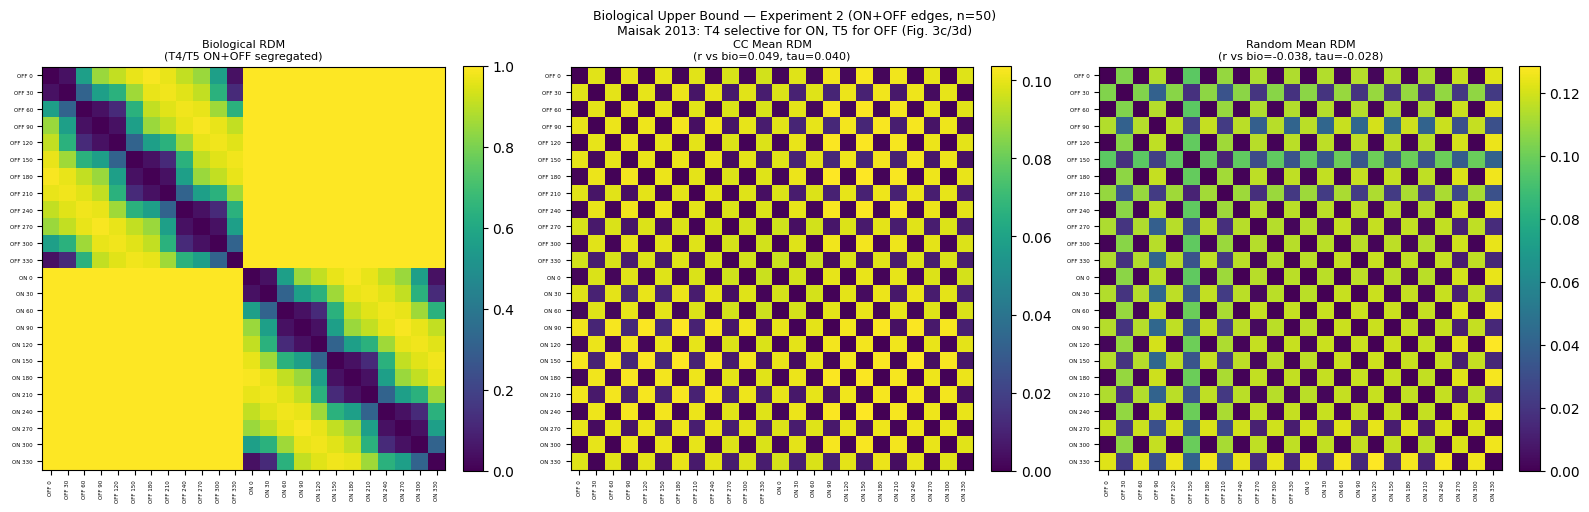


SUMMARY — BIOLOGICAL UPPER BOUND
  Source: Maisak et al. 2013, Fig. 3g/3h
  Subtypes: ['T4a', 'T4b', 'T4c', 'T4d', 'T5a', 'T5b', 'T5c', 'T5d']
  Preferred directions: 0, 90, 180, 270 degrees (T4 and T5)
  Tuning model: von Mises, kappa=2.5, HWHM approx 67 degrees

  Experiment 1 (ON edges, 12 conditions):
    CC vs Bio:    r=0.930, tau=0.783  [analytical]
                  p_perm(r)=0.0000, p_perm(tau)=0.0000  [10000 perms]
    Rand vs Bio:  r=0.603, tau=0.449  [analytical]
                  p_perm(r)=0.0000, p_perm(tau)=0.0000  [10000 perms]
    CC vs Random: r=0.686, tau=0.515  [analytical]

  Experiment 2 (ON+OFF edges, 24 conditions):
    CC vs Bio:    r=0.049, tau=0.040  [analytical]
                  p_perm(r)=0.1594, p_perm(tau)=0.1416  [10000 perms]
    Rand vs Bio:  r=-0.038, tau=-0.028  [analytical]

  Interpretation guide:
  r(CC vs Bio) > r(Rand vs Bio) means CC geometry more consistent with
    biological T4/T5 direction tuning than random geometry
  p_perm < 0.05 means C

In [3]:
# Run Experiment
bio_results = run_biological_upper_bound(results_exp1, results_exp2)

## Results

### Biological Reference RDM
The von Mises tuning model (kappa=2.5, HWHM \~67°, rectified) was fitted to
T4 and T5 direction tuning curves from Maisak et al. 2013 (Fig. 3g/3h), which
were measured using square-wave gratings moving in 12 directions — not moving
edges. The tuning width (60–90° HWHM reported by Maisak et al.) is therefore a
grating-based estimate; kappa=2.5 was selected as a representative value within
this range and is consistent with the published curves. Each of the four T4
subtypes (T4a–d) and four T5 subtypes (T5a–d) is tuned to one of the four
cardinal directions (0°, 90°, 180°, 270°); only 4 of the 12 stimulus directions
align with a subtype's preferred direction, and the remaining 8 fall between
preferred directions. The resulting 12×12 biological stimulus RDM has
off-diagonal values ranging from 0.0460 to 0.9886 — a much wider dynamic range
than either the CC RDM (0.001–0.022) or the stability-constrained random RDM,
reflecting the sharpness of cardinal-direction tuning in the T4/T5 subpopulation.
All Experiment 3 comparisons use the stability-constrained random baseline from
the n=50 full Shiu-style runs (Experiments 1 and 2, MAX\_ATTEMPTS=100),
providing a more stable mean random RDM estimate across 50 independently
accepted configurations than the n=10 comparison baseline.

### Experiment 1 (ON edges, 12 conditions)
CC vs Biology: **Spearman r = 0.930, p \< 0.0001 | Kendall τ = 0.783,
p \< 0.0001** (analytical); **p\_perm \< 0.0001 for both measures** (10,000
permutations, Nili et al. 2014) — zero of 10,000 permutations exceeded the
observed correlation, with observed values falling far outside the right tail of
the null distribution. The CC representational geometry is highly consistent
with the biological T4/T5 direction tuning structure, recovering the circular
ordinal organization of directions in a way that closely mirrors the known
preferred-direction map.

Random vs Biology: **Spearman r = 0.603, p \< 0.0001 | Kendall τ = 0.449,
p \< 0.0001** (analytical); **p\_perm \< 0.0001 for both measures** (10,000
permutations) — zero of 10,000 permutations exceeded the observed correlation.
The random baseline also correlates with the biological RDM, reflecting that
both share the same circular ordinal structure — directions that are angularly
close are more similar than directions that are angularly distant. This is a
consequence of the circular stimulus geometry, not a fidelity signal.

The key comparison is CC vs Random (r = 0.686, τ = 0.515), showing that CC
geometry is substantially closer to biology than random geometry is. The gap
r(CC vs Bio) − r(Rand vs Bio) = **0.327** represents the additional fidelity
attributable to the connectome constraint beyond what circular stimulus
structure alone provides.

### Experiment 2 (ON+OFF edges, 24 conditions)
CC vs Biology: **Spearman r = 0.049, p = 0.422 | Kendall τ = 0.040,
p = 0.368** (analytical); **p\_perm = 0.159 | p\_perm = 0.142** (permutation)
— not significant at α = 0.05 by either measure or inference method. The
observed values fall within the bulk of the null distribution, not merely near
the significance threshold. Random vs Biology: **r = −0.038, τ = −0.028** —
effectively zero and slightly negative.

The near-null result is expected and interpretable. The biological 24×24 RDM
encodes strict ON/OFF pathway segregation — T4 subtypes respond selectively to
ON edges and T5 subtypes to OFF edges (Maisak et al. 2013, Fig. 3c/3d), making
same-direction ON/OFF pairs maximally dissimilar (cosine distance ≈ 1.0, since
their T4/T5 population vectors are orthogonal by construction). The CC 24×24
RDM assigns moderate cross-polarity dissimilarity (\~0.099–0.103) with shared
directional structure — a geometrically different claim. This is a mismatch
between the biological RDM construction and the CC network's actual
representational geometry, not a failure of the CC network. Notably, the
biological RDM does contain within-polarity circular gradients in its ON-ON and
OFF-OFF subblocks; a within-polarity submatrix comparison against the CC
network's ON-ON and OFF-OFF submatrices would be a more appropriate biological
reference for that aspect of the CC geometry and is left as a direction for
future work. A fully matched biological upper bound for the 24-condition case
would additionally require T4/T5 direction tuning curves measured with moving
edges at matched velocities, which are not reported in Maisak et al. 2013. The
Experiment 2 full 24×24 biological comparison is therefore not reported as a
meaningful result.

### Summary
The T4/T5 biological upper bound provides meaningful constraint for the
12-condition ON-edge case: the CC geometry (r = 0.930 vs biology) substantially
exceeds the random geometry (r = 0.603 vs biology), with the gap (Δr = 0.327)
attributable to the connectome constraint above and beyond circular stimulus
structure. The 24-condition full-matrix result is uninterpretable due to a
mismatch between the biological RDM construction and the CC network's actual
representational structure, and is not reported as a meaningful comparison.

## Discussion
- CC geometry (r = 0.930 vs biology) substantially exceeds random geometry
  (r = 0.603 vs biology) in the ON-edge case, with the gap (Δr = 0.327)
  attributable to the connectome constraint above and beyond circular stimulus
  structure; both are significant because the circular stimulus geometry
  produces ordinal structure in any distance-preserving representational space
- The Experiment 2 biological upper bound comparison is uninterpretable at the
  full 24×24 level due to a construction mismatch: the biological 24×24 RDM
  encodes T4/T5 ON/OFF orthogonality per Maisak et al. 2013 Fig. 3c/3d, while
  the CC network encodes moderate cross-polarity dissimilarity with shared
  directional structure; the observed values fall within the bulk of the
  permutation null, confirming the comparison carries no signal
- The biological RDM does contain within-polarity circular gradients in its
  ON-ON and OFF-OFF subblocks; a submatrix-level biological comparison for
  Experiment 2 is a natural extension that would require extracting those blocks
  before computing RDM correlation
- A fully matched biological upper bound for the 24-condition case would
  additionally require moving-edge direction tuning curves from T4/T5 at matched
  velocity; Maisak et al. 2013 report edge polarity selectivity (Fig. 3c/3d) but
  direction tuning width only for gratings (Fig. 3g/3h); the Experiment 1
  biological upper bound remains the primary reference comparison
- The von Mises approximation (kappa=2.5, HWHM \~67°, within the 60–90° range
  reported by Maisak et al. for grating stimuli) does not reproduce
  trial-by-trial variability and is derived from grating rather than edge
  responses; interpret as a qualitative upper bound for the T4/T5 subspace
  (8 of 65 cell types), not a quantitative validation

## Download Saved Figures

In [ ]:
files.download("maisak2013_t4t5_von_mises_tuning.png")
files.download("bio_upper_bound_exp1_permtest.png")
files.download("biological_upper_bound_exp1.png")
files.download("bio_upper_bound_exp2_permtest.png")
files.download("biological_upper_bound_exp2.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>